In [5]:
# print('Hello!')
%pip install torch torchvision torchaudio numpy pandas matplotlib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import sys
print(sys.executable)


c:\Users\neha\AppData\Local\Python\pythoncore-3.11-64\python.exe


Using device: cpu
Epoch 0, Loss: 0.808874 (IC: 0.757606, Phy: 0.051268)
Epoch 500, Loss: 0.018152 (IC: 0.000400, Phy: 0.017752)
Epoch 1000, Loss: 0.013638 (IC: 0.000233, Phy: 0.013404)
Epoch 1500, Loss: 0.010963 (IC: 0.000146, Phy: 0.010817)
Epoch 2000, Loss: 0.008780 (IC: 0.000088, Phy: 0.008692)
Epoch 2500, Loss: 0.007156 (IC: 0.000061, Phy: 0.007094)
Epoch 3000, Loss: 0.006538 (IC: 0.000049, Phy: 0.006489)
Epoch 3500, Loss: 0.006194 (IC: 0.000042, Phy: 0.006152)
Epoch 4000, Loss: 0.005893 (IC: 0.000038, Phy: 0.005856)
Epoch 4500, Loss: 0.005722 (IC: 0.000035, Phy: 0.005688)
Epoch 5000, Loss: 0.005648 (IC: 0.000032, Phy: 0.005617)
Epoch 5500, Loss: 0.005813 (IC: 0.000042, Phy: 0.005771)
Epoch 6000, Loss: 0.005710 (IC: 0.000042, Phy: 0.005668)
Epoch 6500, Loss: 0.005248 (IC: 0.000029, Phy: 0.005219)
Epoch 7000, Loss: 0.005174 (IC: 0.000028, Phy: 0.005147)
Epoch 7500, Loss: 0.005138 (IC: 0.000027, Phy: 0.005111)
Epoch 8000, Loss: 0.004983 (IC: 0.000028, Phy: 0.004956)
Epoch 8500, Loss:

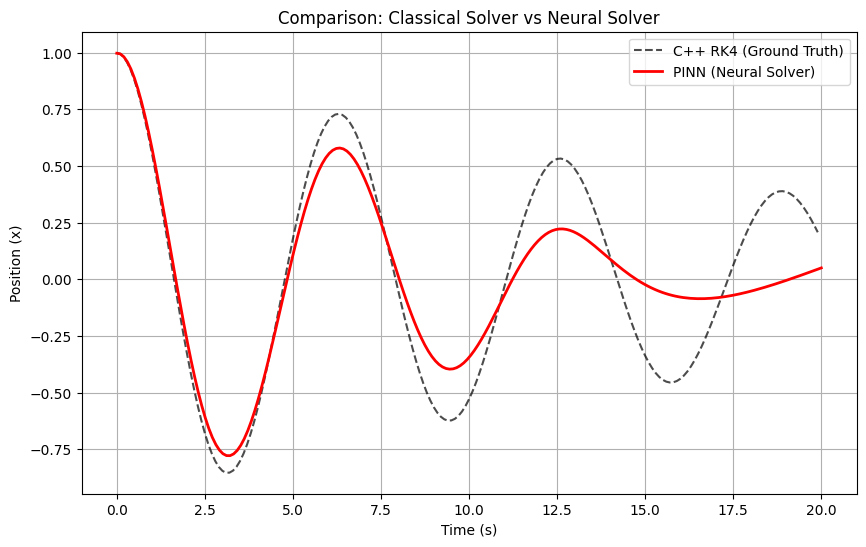

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. The Neural Network (The "Solver")
# Input: Time (t) -> Output: Position (x)
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        # We use Tanh because we need non-zero 2nd derivatives (Acceleration)
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t):
        return self.net(t)

# 2. The Physics Engine (Calculating Loss)
def physics_loss(model, t):
    # Enable gradient tracking for t (needed for derivatives)
    t.requires_grad = True
    
    # Forward pass: Get x from t
    x = model(t)
    
    # First derivative: Velocity (dx/dt)
    # create_graph=True allows us to take the derivative of this derivative later
    v = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    
    # Second derivative: Acceleration (dv/dt or d^2x/dt^2)
    a = torch.autograd.grad(v, t, torch.ones_like(v), create_graph=True)[0]
    
    # Physical Constants (Same as C++ simulation)
    m = 1.0
    k = 1.0
    c = 0.1
    
    # The ODE Residual: m*a + c*v + k*x = 0
    # If the network perfectly follows physics, this should be 0.
    residual = (m * a) + (c * v) + (k * x)
    
    return torch.mean(residual ** 2)

# 3. Training Setup
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Generate "Collocation Points" (Random time points to check physics on)
# We check physics from t=0 to t=20
t_physics = torch.linspace(0, 20, 1000).view(-1, 1).to(device)

# Initial Condition Data: At t=0, x=1
t_initial = torch.tensor([[0.0]]).to(device)
x_initial = torch.tensor([[1.0]]).to(device)
# Note: Ideally we also enforce v(0)=0, but let's keep it simple first.

# 4. The Training Loop
epochs = 200000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Loss 1: Did we match the initial condition? (Data Loss)
    x_pred_initial = model(t_initial)
    loss_ic = torch.mean((x_pred_initial - x_initial) ** 2)
    
    # Loss 2: Did we obey the laws of physics? (Physics Loss)
    loss_phy = physics_loss(model, t_physics)
    
    # Total Loss
    loss = loss_ic + loss_phy
    
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f} (IC: {loss_ic.item():.6f}, Phy: {loss_phy.item():.6f})")

# 5. Evaluation & Comparison
print("Training Complete. Generating plot...")

# Get predictions from PINN
t_test = torch.linspace(0, 20, 200).view(-1, 1).to(device)
with torch.no_grad():
    x_pred = model(t_test).cpu().numpy()

# Load C++ Ground Truth
try:
    df = pd.read_csv("results.csv", skipinitialspace=True)
    
    plt.figure(figsize=(10, 6))
    plt.plot(df['t'], df['rk4_x'], 'k--', label='C++ RK4 (Ground Truth)', alpha=0.7)
    plt.plot(t_test.cpu(), x_pred, 'r-', label='PINN (Neural Solver)', linewidth=2)
    
    plt.title("Comparison: Classical Solver vs Neural Solver")
    plt.xlabel("Time (s)")
    plt.ylabel("Position (x)")
    plt.legend()
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print("Could not find results.csv. Plotting PINN only.")
    plt.plot(t_test.cpu(), x_pred, 'r-', label='PINN')
    plt.show()